In [ ]:
# ============================================================
# SETUP - Run this cell first
# ============================================================
!git clone https://github.com/tatipar/temporalgnn-nids.git
import sys
sys.path.append('/content/temporalgnn-nids/code/python')

from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/nids-mitre/')

In [2]:
!pip install torch_geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.7 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from torch_geometric.loader import DataLoader
from tqdm import tqdm


In [ ]:
from utils.datasets import NF_IDS_Dataset
from utils.models   import StaticGNN_Identity, ST_GNN_Identity


# Functions

In [8]:
def calculate_shannon_entropy(labels, num_categories=7):
    if len(labels) == 0: return 0.0
    # Count the frequency of each port category (0-6)
    counts = torch.bincount(labels, minlength=num_categories).float()
    probs = counts / counts.sum()
    probs = probs[probs > 0] # Avoid log(0)
    return -torch.sum(probs * torch.log2(probs)).item()


In [9]:
def analyze_model_errors_with_entropy(model, loader, device, is_temporal, opt_threshold):
    model.eval()

    if is_temporal and hasattr(model, 'reset_memory'): model.reset_memory()

    results = {
        'TP': [], 'FP': [], 'TN': [], 'FN': []
    }

    threshold_tensor = torch.tensor(opt_threshold, device=device)


    with torch.no_grad():
        for data in tqdm(loader):
            data = data.to(device)

            if is_temporal:
                out = model(data.x, data.edge_index, data.edge_attr, data.global_node_ids)
            else:
                out = model(data.x, data.edge_index, data.edge_attr)

            preds = (torch.sigmoid(out) > threshold_tensor).float().cpu().view(-1)
            targets = data.y.cpu().view(-1)

            # Calculate port entropy for each node
            port_labels = torch.argmax(data.edge_attr[:, 0:7], dim=1)
            src_nodes = data.edge_index[0].cpu()
            dst_nodes = data.edge_index[1].cpu()
            num_nodes = data.x.size(0)

            out_entropies = np.zeros(num_nodes)
            in_entropies = np.zeros(num_nodes)

            unique_src = src_nodes.unique()
            for node in unique_src:
                out_entropies[node] = calculate_shannon_entropy(port_labels[src_nodes == node])

            unique_dst = dst_nodes.unique()
            for node in unique_dst:
                in_entropies[node] = calculate_shannon_entropy(port_labels[dst_nodes == node])


            # Confusion matrix
            for i in range(len(targets)):
                u_src = src_nodes[i].item()
                v_dst = dst_nodes[i].item()
                entropy_pair = (out_entropies[u_src], in_entropies[v_dst])
                p = preds[i].item()
                t = targets[i].item()

                if p == 1 and t == 1: results['TP'].append(entropy_pair)
                elif p == 1 and t == 0: results['FP'].append(entropy_pair) # False Alarm
                elif p == 0 and t == 0: results['TN'].append(entropy_pair)
                elif p == 0 and t == 1: results['FN'].append(entropy_pair) # Attack omitted


    # --- Visualization ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    categories = ['TP', 'FP', 'TN', 'FN']

    out_data = [ [x[0] for x in results[cat]] for cat in categories ]
    in_data = [ [x[1] for x in results[cat]] for cat in categories ]

    x = np.arange(len(categories))

    # Out-Entropy
    sns.boxplot(data=out_data, ax=ax1)
    ax1.set_xticks(x)
    ax1.set_xticklabels(categories)
    ax1.set_title("Out-Entropy (Comportamiento del Origen)")
    ax1.set_ylabel("Entropía de Salida")

    # In-Entropy
    sns.boxplot(data=in_data, ax=ax2)
    ax2.set_xticks(x)
    ax2.set_xticklabels(categories)
    ax2.set_title("In-Entropy (Comportamiento del Destino)")
    ax2.set_ylabel("Entropía de Entrada")

    plt.tight_layout()
    plt.show()

    # Numerical report
    print("\n--- SUMMARY (Means Out / In) ---")
    for cat in categories:
        if len(results[cat]) > 0:
            m_out = np.mean([x[0] for x in results[cat]])
            m_in = np.mean([x[1] for x in results[cat]])
            print(f"{cat}: Out={m_out:.4f} | In={m_in:.4f} (n={len(results[cat])})")


# Configuration

In [10]:
ROOT_PATH = "./dataset_processed"

val_dataset = NF_IDS_Dataset(root_dir=ROOT_PATH, split='val')
print(f"Val size: {len(val_dataset)}")
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0, persistent_workers=False, pin_memory=False)

Val size: 428


In [11]:
# ── Model hyperparameters ───────────────────────
NODE_DIM   = 16
EDGE_DIM   = 32    # 7 (port) + 5 (protocol) + 20 (numeric)
HIDDEN_DIM = 32
DROPOUT    = 0.2
BIAS_VALUE = -2.9968

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device   : {DEVICE}")


Device   : cpu


# Main

## Static GNN

In [12]:
MODEL_PATH = "/content/drive/MyDrive/nids-mitre/results_earlystopping/saved_models/StaticGNN_BiasOn_robust_Identity/StaticGNN_BiasOn_robust_Identity_seed42_20260220_163311_AUC-PR_0.4811.pth"

opt_thresholds = np.load("/content/drive/MyDrive/nids-mitre/results_earlystopping/logs/StaticGNN_BiasOn_robust_Identity/thresholds_StaticGNN_BiasOn_robust_Identity.npz")
THRESHOLD  = opt_thresholds["seed_42"]

model_staticgnn = StaticGNN_Identity(
    node_dim   = NODE_DIM,
    edge_dim   = EDGE_DIM,
    hidden_dim = HIDDEN_DIM,
    dropout    = DROPOUT,
    output_bias_init = BIAS_VALUE
).to(DEVICE)

model_staticgnn.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))


<All keys matched successfully>

100%|██████████| 428/428 [01:20<00:00,  5.32it/s]


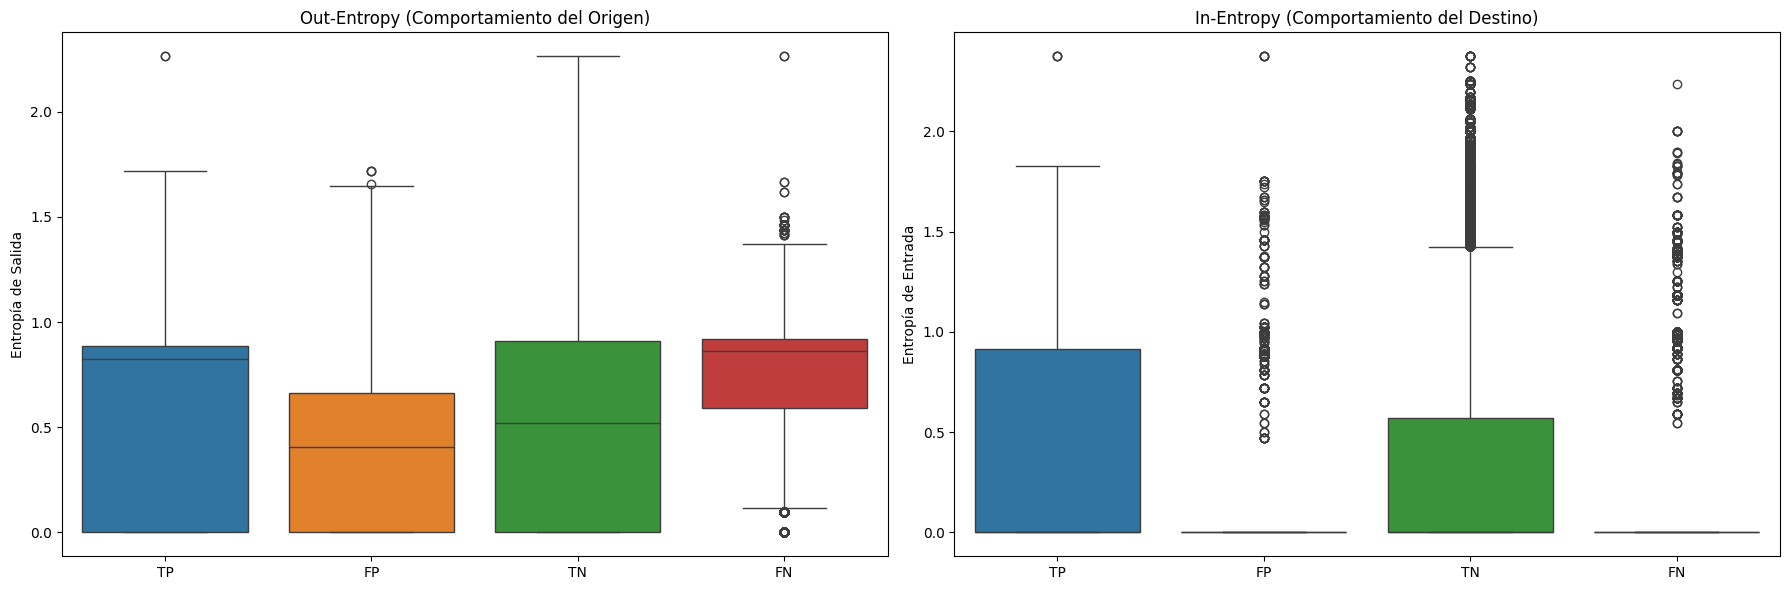


--- SUMMARY (Means Out / In) ---
TP: Out=0.5510 | In=0.5282 (n=12666)
FP: Out=0.4129 | In=0.0762 (n=7645)
TN: Out=0.4763 | In=0.2756 (n=749561)
FN: Out=0.6805 | In=0.0474 (n=18663)


In [13]:
analyze_model_errors_with_entropy(model_staticgnn, val_loader, DEVICE, False, THRESHOLD)


## ST GNN

In [ ]:
MODEL_PATH = "/content/drive/MyDrive/nids-mitre/results_earlystopping/saved_models/ST_GNN_BiasOn_robust_Identity_clone/ST_GNN_BiasOn_robust_Identity_clone_seed42_20260220_213225_AUC-PR_0.7718.pth"

opt_thresholds = np.load("/content/drive/MyDrive/nids-mitre/results_earlystopping/logs/ST_GNN_BiasOn_robust_Identity_clone/thresholds_ST_GNN_BiasOn_robust_Identity_clone.npz")
THRESHOLD  = opt_thresholds["seed_42"]

model_stgnn = ST_GNN_Identity(
    node_dim   = NODE_DIM,
    edge_dim   = EDGE_DIM,
    hidden_dim = HIDDEN_DIM,
    dropout    = DROPOUT,
    output_bias_init = BIAS_VALUE
).to(DEVICE)

model_stgnn.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))


<All keys matched successfully>

100%|██████████| 428/428 [01:21<00:00,  5.28it/s]


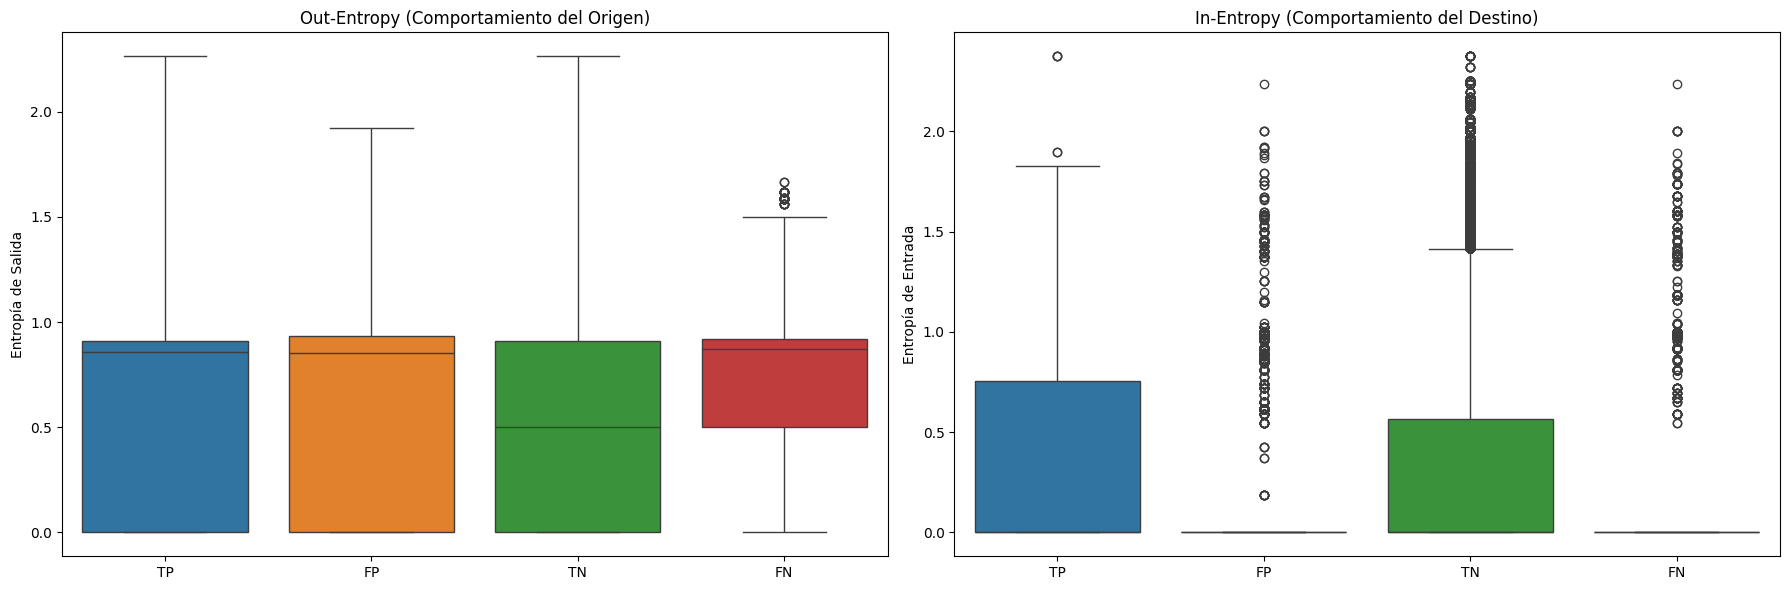


--- SUMMARY (Means Out / In) ---
TP: Out=0.6164 | In=0.2710 (n=25712)
FP: Out=0.6107 | In=0.1310 (n=9507)
TN: Out=0.4739 | In=0.2754 (n=747699)
FN: Out=0.6819 | In=0.1080 (n=5617)


In [ ]:
analyze_model_errors_with_entropy(model_stgnn, val_loader, DEVICE, True, THRESHOLD)
